In [1]:
# ============================================================
# MAPCT-v2: FULL CORRECTED PIPELINE (Leakage-free, Padding fixed)
# ============================================================
# 1. Imports & reproducibility
# 2. Data loading & normalisation
# 3. Mechanism embeddings (structured + semantic)
# 4. Leakage‑free split by regimen
# 5. Drug vocabulary & multi‑hot targets
# 6. Clinical preprocessing
# 7. Drug sequence tensors (with padding)
# 8. Model definitions (ClinicalEncoder, DrugEncoder, Decoders)
# 9. Loss functions (InfoNCE)
# 10. Training loop with early stopping
# 11. Final test evaluation
# ============================================================

import os, re, random, hashlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_squared_error
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sentence_transformers import SentenceTransformer

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
warnings.filterwarnings('ignore')

# ------------------------------------------------------------
# Data loading (Google Drive)
# ------------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

file_path1 = '/content/drive/MyDrive/khezri/drug_data/merged_drug.xlsx'
file_path2 = '/content/drive/MyDrive/khezri/drug_data/drug_mechanism.xlsx'

clinic_df = pd.read_excel(file_path1, engine="openpyxl")
mech_df = pd.read_excel(file_path2, engine="openpyxl")
print(f"Loaded {len(clinic_df)} patients, {len(mech_df)} mechanism entries")

# ------------------------------------------------------------
# Drug name normalisation helpers
# ------------------------------------------------------------
def normalize_drug_name(name: str) -> str:
    if not isinstance(name, str): return ""
    name = name.lower().strip()
    name = re.sub(r"\([^)]*\)", "", name)
    name = re.sub(r"\s+brand:.*", "", name)
    name = re.sub(r"\s*\+\s*", ", ", name)
    name = re.sub(r"\s*,\s*", ", ", name)
    return name

def sort_drug_combo(combo: str) -> str:
    if not isinstance(combo, str): return ""
    drugs = sorted(d.strip() for d in combo.split(",") if d.strip())
    return ", ".join(drugs)

def split_combo(combo: str):
    return [d.strip() for d in combo.split(",") if d.strip()]

# Normalise clinic and mechanism tables
clinic_df["merged_drugs_norm"] = (clinic_df["merged_drugs"].astype(str)
                                  .apply(normalize_drug_name)
                                  .apply(sort_drug_combo))
mech_df["Drug Name Norm"] = (mech_df["Drug Name"].astype(str)
                             .apply(normalize_drug_name)
                             .apply(sort_drug_combo))
print("✅ Drug names normalized")

# ------------------------------------------------------------
# Mechanism embeddings (structured + semantic)
# ------------------------------------------------------------
def stable_hash(x: str, mod: int) -> int:
    return int(hashlib.md5(x.encode()).hexdigest(), 16) % mod

class StructuredMechanismEncoder:
    def __init__(self, struct_dim=128):
        self.struct_dim = struct_dim
        self.n_fields = 8
        self.slice_len = struct_dim // self.n_fields
        self.offsets = {k: i*self.slice_len for i,k in enumerate(
            ["chembl","target_ids","uniprot_ids","mesh_ids",
             "pathway_ids","atc_codes","pharm_class","mechanism_ids"])}
        self.field_columns = {
            "chembl":"ChEMBL ID","target_ids":"Target IDs","uniprot_ids":"UniProt Target ID(s)",
            "mesh_ids":"MeSH Mechanism ID(s)","pathway_ids":"Pathway IDs",
            "atc_codes":"ATC Code(s)","pharm_class":"Pharmacologic Class","mechanism_ids":"Mechanism IDs"
        }
    def encode_field(self, values, field_name):
        vector = torch.zeros(self.slice_len)
        if values is None: return vector
        if isinstance(values, pd.Series): values = values.dropna().tolist()
        elif isinstance(values, str): values = [v.strip() for v in values.split(";") if v.strip()]
        elif not isinstance(values, (list,tuple)): values = [values]
        for v in values:
            v_str = str(v).strip()
            if v_str and v_str not in ["","nan","None"]:
                idx = stable_hash(v_str, self.slice_len)
                vector[idx] += 1.0
        return vector
    def encode(self, row):
        vector = torch.zeros(self.struct_dim)
        for fname, col in self.field_columns.items():
            if col in row.index:
                vec = self.encode_field(row[col], fname)
                off = self.offsets[fname]
                vector[off:off+self.slice_len] = vec
        if torch.norm(vector) > 0: vector = vector / torch.norm(vector)
        return vector

# Semantic model
semantic_model = SentenceTransformer("all-MiniLM-L6-v2", device=device)
sem_dim = semantic_model.get_sentence_embedding_dimension()
struct_dim = 128
full_embed_dim = struct_dim + sem_dim
print(f"Structured dim: {struct_dim}, Semantic dim: {sem_dim}, Total: {full_embed_dim}")

def build_mechanism_embeddings(drug_list, mech_df):
    struct_enc = StructuredMechanismEncoder(struct_dim=struct_dim)
    embeddings = {}
    for drug in tqdm(drug_list, desc="Building embeddings"):
        row = mech_df[mech_df["Drug Name Norm"] == drug]
        if len(row) == 0:
            embeddings[drug] = torch.zeros(full_embed_dim)
            continue
        row = row.iloc[0]
        struct_vec = struct_enc.encode(row)
        text_parts = []
        for col in ["Mechanisms","Description","Target IDs","Pathway IDs","ATC Code(s)"]:
            if col in row and pd.notna(row[col]):
                text_parts.append(str(row[col]))
        if text_parts:
            full_text = " | ".join(text_parts)
            with torch.no_grad():
                sem_vec = semantic_model.encode(full_text, convert_to_tensor=True).cpu()
                sem_vec = F.normalize(sem_vec, dim=0)
        else:
            sem_vec = torch.zeros(sem_dim)
        fused = torch.cat([struct_vec, sem_vec], dim=0)
        if torch.norm(fused) > 0:
            fused = fused / torch.norm(fused)
        embeddings[drug] = fused
    return embeddings

# ------------------------------------------------------------
# Leakage‑free split by regimen (GroupKFold)
# ------------------------------------------------------------
print("\n🔪 Performing leakage‑free split by regimen...")
groups = clinic_df["merged_drugs_norm"]
gkf = GroupKFold(n_splits=5)
train_val_idx, test_idx = next(iter(gkf.split(clinic_df, groups=groups)))
train_idx, val_idx = train_test_split(train_val_idx, test_size=0.2, random_state=SEED)
print(f"Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")

# ------------------------------------------------------------
# Drug vocabulary (0‑based for multi‑hot targets)
# ------------------------------------------------------------
def build_drug_vocabulary(train_df):
    all_drugs = set()
    for combo in train_df["merged_drugs_norm"]:
        for drug in split_combo(combo):
            all_drugs.add(drug)
    drug_to_idx = {drug: i for i, drug in enumerate(sorted(all_drugs))}
    idx_to_drug = {i: drug for drug, i in drug_to_idx.items()}
    return drug_to_idx, idx_to_drug, len(drug_to_idx)

def encode_regimen_multi_hot(combo, drug_to_idx, num_drugs):
    vec = np.zeros(num_drugs, dtype=np.float32)
    for drug in split_combo(combo):
        idx = drug_to_idx.get(drug, -1)
        if idx != -1:
            vec[idx] = 1.0
    return vec

drug_to_idx, idx_to_drug, num_drugs = build_drug_vocabulary(clinic_df.iloc[train_idx])
print(f"Drug vocabulary size: {num_drugs}")

def make_multi_hot_matrix(df, drug_to_idx, num_drugs):
    mat = np.zeros((len(df), num_drugs), dtype=np.float32)
    for i, combo in enumerate(df["merged_drugs_norm"]):
        mat[i] = encode_regimen_multi_hot(combo, drug_to_idx, num_drugs)
    return torch.tensor(mat, dtype=torch.float32)

y_drug_train = make_multi_hot_matrix(clinic_df.iloc[train_idx], drug_to_idx, num_drugs).to(device)
y_drug_val   = make_multi_hot_matrix(clinic_df.iloc[val_idx],   drug_to_idx, num_drugs).to(device)
y_drug_test  = make_multi_hot_matrix(clinic_df.iloc[test_idx],  drug_to_idx, num_drugs).to(device)

# ------------------------------------------------------------
# Clinical preprocessing (fit on train only)
# ------------------------------------------------------------
numeric_cols = ["fbs","glu","hba1c","TG","cho","LDL","HDL","UA","Na","K","Ca","Vit D","age"]
categorical_cols = ["sex","fbs_category","tg_category","cho_category"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_cols),
    ("cat", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), categorical_cols)
], remainder="drop")

X_train_raw = clinic_df.iloc[train_idx][numeric_cols + categorical_cols]
X_val_raw   = clinic_df.iloc[val_idx][numeric_cols + categorical_cols]
X_test_raw  = clinic_df.iloc[test_idx][numeric_cols + categorical_cols]

X_clin_train = torch.tensor(preprocessor.fit_transform(X_train_raw), dtype=torch.float32).to(device)
X_clin_val   = torch.tensor(preprocessor.transform(X_val_raw), dtype=torch.float32).to(device)
X_clin_test  = torch.tensor(preprocessor.transform(X_test_raw), dtype=torch.float32).to(device)
print(f"Clinical feature dim: {X_clin_train.shape[1]}")

# ------------------------------------------------------------
# Build drug sequence tensors (using mechanism embeddings, zero padding)
# ------------------------------------------------------------
MAX_DRUGS = 10

# First build embeddings for ALL drugs that appear in the training split
train_drug_set = set()
for combo in clinic_df.iloc[train_idx]["merged_drugs_norm"]:
    train_drug_set.update(split_combo(combo))
drug_embeddings = build_mechanism_embeddings(train_drug_set, mech_df)
print(f"Built embeddings for {len(drug_embeddings)} drugs, dim={full_embed_dim}")

def build_drug_sequence(combo):
    drugs = split_combo(combo)[:MAX_DRUGS]
    seq = [drug_embeddings.get(d, torch.zeros(full_embed_dim)) for d in drugs]
    mask = torch.zeros(MAX_DRUGS, dtype=torch.bool)
    mask[:len(seq)] = True
    if len(seq) < MAX_DRUGS:
        seq += [torch.zeros(full_embed_dim)] * (MAX_DRUGS - len(seq))
    return torch.stack(seq), mask

def build_sequences(df, indices):
    seqs, masks = [], []
    for idx in indices:
        combo = df.iloc[idx]["merged_drugs_norm"]
        seq, mask = build_drug_sequence(combo)
        seqs.append(seq); masks.append(mask)
    return torch.stack(seqs).to(device), torch.stack(masks).to(device)

X_drug_train, mask_train = build_sequences(clinic_df, train_idx)
X_drug_val,   mask_val   = build_sequences(clinic_df, val_idx)
X_drug_test,  mask_test  = build_sequences(clinic_df, test_idx)

# Role tensor (not used, kept for compatibility)
role_train = torch.zeros(X_drug_train.shape[0], MAX_DRUGS, dtype=torch.long).to(device)
role_val   = torch.zeros(X_drug_val.shape[0],   MAX_DRUGS, dtype=torch.long).to(device)
role_test  = torch.zeros(X_drug_test.shape[0],  MAX_DRUGS, dtype=torch.long).to(device)

print(f"Drug sequences: train {X_drug_train.shape}, val {X_drug_val.shape}, test {X_drug_test.shape}")

# ------------------------------------------------------------
# Model definitions (MAPCT‑v2)
# ------------------------------------------------------------
latent_dim = 64

class ClinicalEncoder(nn.Module):
    def __init__(self, input_dim, latent_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(256, latent_dim)
        )
    def forward(self, x):
        return F.normalize(self.net(x), dim=1)

class DrugEncoder(nn.Module):
    def __init__(self, emb_dim, latent_dim=64, n_heads=4, n_layers=2, max_drugs=10):
        super().__init__()
        self.pos_emb = nn.Parameter(torch.randn(1, max_drugs, emb_dim) * 0.01)
        encoder_layer = nn.TransformerEncoderLayer(d_model=emb_dim, nhead=n_heads,
                                                   batch_first=True, dropout=0.1)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.proj = nn.Linear(emb_dim, latent_dim)
    def forward(self, drug_seq, mask, roles=None):
        x = drug_seq + self.pos_emb[:, :drug_seq.size(1), :]
        x = self.transformer(x, src_key_padding_mask=~mask)
        mask_exp = mask.unsqueeze(-1).float()
        pooled = (x * mask_exp).sum(dim=1) / mask_exp.sum(dim=1).clamp(min=1)
        return F.normalize(self.proj(pooled), dim=1)

class ClinicalDecoder(nn.Module):
    def __init__(self, latent_dim=64, output_dim=None):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2*latent_dim, 256), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(256, output_dim)
        )
    def forward(self, z_clin, z_drug):
        return self.net(torch.cat([z_clin, z_drug], dim=1))

class DrugDecoder(nn.Module):
    def __init__(self, latent_dim=64, num_drugs=None):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(256, num_drugs)
        )
    def forward(self, z_clin):
        return self.net(z_clin)

# Initialise models
clinical_encoder = ClinicalEncoder(X_clin_train.shape[1], latent_dim).to(device)
drug_encoder = DrugEncoder(emb_dim=full_embed_dim, latent_dim=latent_dim).to(device)
clinical_decoder = ClinicalDecoder(latent_dim, output_dim=X_clin_train.shape[1]).to(device)
drug_decoder = DrugDecoder(latent_dim, num_drugs=num_drugs).to(device)

optimizer = torch.optim.Adam(
    list(clinical_encoder.parameters()) + list(drug_encoder.parameters()) +
    list(clinical_decoder.parameters()) + list(drug_decoder.parameters()),
    lr=1e-3
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=10, factor=0.5)

# ------------------------------------------------------------
# Loss functions
# ------------------------------------------------------------
def contrastive_loss(z1, z2, temperature=0.07):
    logits = z1 @ z2.T / temperature
    labels = torch.arange(z1.size(0), device=z1.device)
    loss_fwd = F.cross_entropy(logits, labels)
    loss_rev = F.cross_entropy(logits.T, labels)
    return (loss_fwd + loss_rev) / 2

alpha_recon = 0.3
alpha_contrast = 1.0
alpha_drug = 0.5

# ------------------------------------------------------------
# Training loop with early stopping
# ------------------------------------------------------------
num_epochs = 70
batch_size = 64
best_val_loss = float('inf')
patience_counter = 0
max_patience = 15

train_losses, val_combined_losses, val_contrast_sims, val_drug_f1s = [], [], [], []

print("\n" + "="*60)
print("TRAINING MAPCT‑v2 (Leakage‑free, padded properly)")
print("="*60)

for epoch in range(num_epochs):
    clinical_encoder.train()
    drug_encoder.train()
    clinical_decoder.train()
    drug_decoder.train()

    total_loss = total_recon = total_contrast = total_drug = 0
    n_samples = len(X_clin_train)
    indices = np.random.permutation(n_samples)
    n_batches = (n_samples + batch_size - 1) // batch_size

    pbar = tqdm(range(n_batches), desc=f"Epoch {epoch+1}/{num_epochs}")
    for batch_idx in pbar:
        start = batch_idx * batch_size
        end = min(start + batch_size, n_samples)
        batch_indices = indices[start:end]

        x_clin = X_clin_train[batch_indices]
        x_drug = X_drug_train[batch_indices]
        x_mask = mask_train[batch_indices]
        x_role = role_train[batch_indices]
        y_drug = y_drug_train[batch_indices]

        z_clin = clinical_encoder(x_clin)
        z_drug = drug_encoder(x_drug, x_mask, x_role)

        loss_recon = F.mse_loss(clinical_decoder(z_clin, z_drug), x_clin)
        loss_contrast = contrastive_loss(z_clin, z_drug)
        drug_logits = drug_decoder(z_clin)
        loss_drug = F.binary_cross_entropy_with_logits(drug_logits, y_drug)

        loss = alpha_recon * loss_recon + alpha_contrast * loss_contrast + alpha_drug * loss_drug

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(clinical_encoder.parameters()) + list(drug_encoder.parameters()) +
            list(clinical_decoder.parameters()) + list(drug_decoder.parameters()),
            max_norm=1.0
        )
        optimizer.step()

        total_loss += loss.item()
        total_recon += loss_recon.item()
        total_contrast += loss_contrast.item()
        total_drug += loss_drug.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'contrast': f'{loss_contrast.item():.3f}'})

    avg_loss = total_loss / n_batches
    avg_recon = total_recon / n_batches
    avg_contrast = total_contrast / n_batches
    avg_drug = total_drug / n_batches

    # Validation
    clinical_encoder.eval()
    drug_encoder.eval()
    clinical_decoder.eval()
    drug_decoder.eval()

    val_recon = val_contrast_sim = val_drug_f1 = val_drug_acc = 0.0
    with torch.no_grad():
        n_val = len(X_clin_val)
        for start in range(0, n_val, batch_size):
            end = min(start + batch_size, n_val)
            x_clin = X_clin_val[start:end]
            x_drug = X_drug_val[start:end]
            x_mask = mask_val[start:end]
            x_role = role_val[start:end]
            y_drug = y_drug_val[start:end]

            z_clin = clinical_encoder(x_clin)
            z_drug = drug_encoder(x_drug, x_mask, x_role)

            val_recon += F.mse_loss(clinical_decoder(z_clin, z_drug), x_clin).item() * len(x_clin)
            sim = (z_clin * z_drug).sum(dim=1).mean().item()
            val_contrast_sim += sim * len(x_clin)

            logits = drug_decoder(z_clin)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > 0.3).astype(np.float32)
            true = y_drug.cpu().numpy()
            val_drug_f1 += f1_score(true, preds, average='micro', zero_division=0) * len(x_clin)
            val_drug_acc += accuracy_score(true.flatten(), preds.flatten()) * len(x_clin)

    n_val_total = len(X_clin_val)
    val_recon_loss = val_recon / n_val_total
    val_contrast_sim = val_contrast_sim / n_val_total
    val_drug_f1 = val_drug_f1 / n_val_total
    val_drug_acc = val_drug_acc / n_val_total

    val_combined = alpha_recon * val_recon_loss - alpha_contrast * val_contrast_sim + alpha_drug * (1 - val_drug_f1)
    train_losses.append(avg_loss)
    val_combined_losses.append(val_combined)
    val_contrast_sims.append(val_contrast_sim)
    val_drug_f1s.append(val_drug_f1)

    scheduler.step(val_combined)
    current_lr = optimizer.param_groups[0]['lr']

    if val_combined < best_val_loss:
        best_val_loss = val_combined
        patience_counter = 0
        torch.save({
            'clinical_encoder': clinical_encoder.state_dict(),
            'drug_encoder': drug_encoder.state_dict(),
            'clinical_decoder': clinical_decoder.state_dict(),
            'drug_decoder': drug_decoder.state_dict(),
            'epoch': epoch,
            'val_loss': best_val_loss,
        }, 'best_mapct_v2_model.pt')
    else:
        patience_counter += 1

    if (epoch+1) % 5 == 0:
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print(f"  Train - Loss: {avg_loss:.4f}, Recon: {avg_recon:.4f}, Contrast: {avg_contrast:.4f}, Drug: {avg_drug:.4f}")
        print(f"  Valid - Recon: {val_recon_loss:.4f}, Contrast Sim: {val_contrast_sim:.4f}")
        print(f"  Valid - Drug F1: {val_drug_f1:.4f}, Drug Acc: {val_drug_acc:.4f}")
        print(f"  Valid - Combined Loss: {val_combined:.4f}, LR: {current_lr:.6f}, Patience: {patience_counter}/{max_patience}")

    if patience_counter >= max_patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

# Load best model
checkpoint = torch.load('best_mapct_v2_model.pt', map_location=device, weights_only=False)
clinical_encoder.load_state_dict(checkpoint['clinical_encoder'])
drug_encoder.load_state_dict(checkpoint['drug_encoder'])
clinical_decoder.load_state_dict(checkpoint['clinical_decoder'])
drug_decoder.load_state_dict(checkpoint['drug_decoder'])
print(f"\n✅ Loaded best model from epoch {checkpoint['epoch']+1} with validation combined loss {checkpoint['val_loss']:.4f}")

# ------------------------------------------------------------
# Final test evaluation
# ------------------------------------------------------------
clinical_encoder.eval()
drug_encoder.eval()
clinical_decoder.eval()
drug_decoder.eval()

test_recon = test_contrast_sim = test_drug_f1 = test_drug_acc = 0.0
with torch.no_grad():
    n_test = len(X_clin_test)
    for start in range(0, n_test, batch_size):
        end = min(start + batch_size, n_test)
        x_clin = X_clin_test[start:end]
        x_drug = X_drug_test[start:end]
        x_mask = mask_test[start:end]
        x_role = role_test[start:end]
        y_drug = y_drug_test[start:end]

        z_clin = clinical_encoder(x_clin)
        z_drug = drug_encoder(x_drug, x_mask, x_role)

        test_recon += F.mse_loss(clinical_decoder(z_clin, z_drug), x_clin).item() * len(x_clin)
        test_contrast_sim += (z_clin * z_drug).sum(dim=1).mean().item() * len(x_clin)

        logits = drug_decoder(z_clin)
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs > 0.3).astype(np.float32)
        true = y_drug.cpu().numpy()
        test_drug_f1 += f1_score(true, preds, average='micro', zero_division=0) * len(x_clin)
        test_drug_acc += accuracy_score(true.flatten(), preds.flatten()) * len(x_clin)

n_test_total = len(X_clin_test)
test_recon_loss = test_recon / n_test_total
test_contrast_sim = test_contrast_sim / n_test_total
test_drug_f1 = test_drug_f1 / n_test_total
test_drug_acc = test_drug_acc / n_test_total

print("\n" + "="*60)
print("FINAL TEST SET PERFORMANCE")
print("="*60)
print(f"Reconstruction MSE:  {test_recon_loss:.6f}")
print(f"Contrastive similarity (clinical ↔ drug): {test_contrast_sim:.4f}")
print(f"Drug prediction F1:   {test_drug_f1:.4f}")
print(f"Drug prediction Acc:  {test_drug_acc:.4f}")
print("\n✅ Refined MAPCT‑v2 training complete.")

Using device: cpu
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 4547 patients, 164 mechanism entries
✅ Drug names normalized


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...


Epoch 40/70
  Train - Loss: 3.8203, Recon: 0.1126, Contrast: 3.7631, Drug: 0.0467
  Valid - Recon: 0.1121, Contrast Sim: 0.3799
  Valid - Drug F1: 0.5156, Drug Acc: 0.9805
  Valid - Combined Loss: -0.1041, LR: 0.001000, Patience: 9/15


Epoch 45/70: 100%|██████████| 46/46 [00:35<00:00,  1.30it/s, loss=3.1574, contrast=3.121]



Epoch 45/70
  Train - Loss: 3.7226, Recon: 0.1065, Contrast: 3.6676, Drug: 0.0460
  Valid - Recon: 0.1072, Contrast Sim: 0.3635
  Valid - Drug F1: 0.5102, Drug Acc: 0.9805
  Valid - Combined Loss: -0.0864, LR: 0.000500, Patience: 14/15


Epoch 46/70: 100%|██████████| 46/46 [00:33<00:00,  1.36it/s, loss=2.8621, contrast=2.819]



Early stopping at epoch 46

✅ Loaded best model from epoch 31 with validation combined loss -0.1223

FINAL TEST SET PERFORMANCE
Reconstruction MSE:  0.042206
Contrastive similarity (clinical ↔ drug): 0.3990
Drug prediction F1:   0.4878
Drug prediction Acc:  0.9849

✅ Refined MAPCT‑v2 training complete.


In [2]:
# ============================================================
# PATIENT ANALYSIS (Single example – no interactive loop)
# ============================================================

# Build test dataframe (required!)
test_df = clinic_df.iloc[test_idx].reset_index(drop=True)

def show_patient_analysis(
    patient_idx,
    clinical_encoder, drug_encoder, drug_decoder,
    X_clin_test, X_drug_test, mask_test, role_test, y_drug_test,
    test_df, idx_to_drug, drug_to_idx, device,
    threshold=0.3, top_k_similar=5
):
    if patient_idx < 0 or patient_idx >= len(X_clin_test):
        print(f"❌ Patient index {patient_idx} out of range")
        return

    clinical_encoder.eval()
    drug_encoder.eval()
    drug_decoder.eval()

    with torch.no_grad():
        x_clin = X_clin_test[patient_idx:patient_idx+1]
        x_drug = X_drug_test[patient_idx:patient_idx+1]
        x_mask = mask_test[patient_idx:patient_idx+1]
        x_role = role_test[patient_idx:patient_idx+1]

        z_clin = clinical_encoder(x_clin)
        z_drug = drug_encoder(x_drug, x_mask, x_role)
        logits = drug_decoder(z_clin)
        probs = torch.sigmoid(logits).cpu().numpy()[0]
        align_score = float((z_clin * z_drug).sum())

    patient_row = test_df.iloc[patient_idx]
    true_combo = patient_row["merged_drugs_norm"]
    true_drugs = set(split_combo(true_combo))

    pred_drugs = [(idx_to_drug[i], float(p)) for i, p in enumerate(probs) if p >= threshold]
    pred_drugs.sort(key=lambda x: x[1], reverse=True)

    print("\n" + "="*70)
    print(f"🩺 PATIENT #{patient_idx} (Test Set)")
    print("="*70)
    print("\n📊 CLINICAL PROFILE:")
    for col in numeric_cols + categorical_cols:
        if col in patient_row:
            val = patient_row[col]
            print(f"   {col:<15}: {val:.2f}" if isinstance(val, float) else f"   {col:<15}: {val}")

    print("\n💊 ACTUAL PRESCRIBED REGIMEN:")
    print(f"   {true_combo if true_combo else 'None'}")
    print(f"\n🤖 MODEL PREDICTED REGIMEN (threshold={threshold:.2f}):")
    if pred_drugs:
        for drug, prob in pred_drugs[:10]:
            marker = "✓" if drug in true_drugs else " "
            print(f"   [{marker}] {drug:<35} prob={prob:.4f}")
    else:
        print("   No drugs predicted above threshold.")

    print(f"\n🔗 CLINICAL–DRUG ALIGNMENT (cosine similarity): {align_score:.4f}")
    if align_score > 0.5:
        print("   ✅ Good alignment")
    else:
        print("   ⚠️ Low alignment")

    pred_set = {d for d, _ in pred_drugs}
    if pred_set == true_drugs:
        print("\n✅ RECOMMENDATION: Exact match.")
    elif pred_set & true_drugs:
        print("\n⚠️ RECOMMENDATION: Partial match. Consider:", ", ".join([d for d, _ in pred_drugs[:5]]))
    else:
        print("\n⚠️ RECOMMENDATION: Different regimen suggested:", ", ".join([d for d, _ in pred_drugs[:5]]) if pred_drugs else "None")

    # Similar patients
    with torch.no_grad():
        all_z = []
        for i in range(0, len(X_clin_test), 128):
            batch = clinical_encoder(X_clin_test[i:i+128]).cpu().numpy()
            all_z.append(batch)
        all_z = np.vstack(all_z)
    current_z = z_clin.cpu().numpy().reshape(-1)
    sims = all_z @ current_z
    sims[patient_idx] = -np.inf
    top_indices = np.argsort(-sims)[:top_k_similar]
    print(f"\n👥 TOP {top_k_similar} SIMILAR PATIENTS:")
    for rank, idx in enumerate(top_indices, 1):
        print(f"   {rank}. Similarity={sims[idx]:.4f} | Regimen: {test_df.iloc[idx]['merged_drugs_norm']}")
    print("\n" + "="*70)


# Show one example (patient 0) – no interactive loop
print("\n" + "="*70)
print("🔍 EXAMPLE PATIENT ANALYSIS (Patient #0)")
print("="*70)
show_patient_analysis(
    patient_idx=0,
    clinical_encoder=clinical_encoder,
    drug_encoder=drug_encoder,
    drug_decoder=drug_decoder,
    X_clin_test=X_clin_test,
    X_drug_test=X_drug_test,
    mask_test=mask_test,
    role_test=role_test,
    y_drug_test=y_drug_test,
    test_df=test_df,
    idx_to_drug=idx_to_drug,
    drug_to_idx=drug_to_idx,
    device=device,
    threshold=0.3,
    top_k_similar=5
)


🔍 EXAMPLE PATIENT ANALYSIS (Patient #0)

🩺 PATIENT #0 (Test Set)

📊 CLINICAL PROFILE:
   fbs            : 115.00
   glu            : 326.00
   hba1c          : 7.50
   TG             : 277.00
   cho            : 254.00
   LDL            : 173.00
   HDL            : 38.00
   UA             : 5.33
   Na             : 138.67
   K              : 4.50
   Ca             : 9.43
   Vit D          : 26.50
   age            : 59.00
   sex            : 0
   fbs_category   : Moderate controlled
   tg_category    : High (Elevated risk)
   cho_category   : High (cardiovascular risk)

💊 ACTUAL PRESCRIBED REGIMEN:
   acarbose, aspirin, atorvastatin, clopidogrel, gliclazide, insulin glargine, metoprolol, nitroglycerin

🤖 MODEL PREDICTED REGIMEN (threshold=0.30):
   [ ] metformin                           prob=0.8105
   [✓] atorvastatin                        prob=0.3494

🔗 CLINICAL–DRUG ALIGNMENT (cosine similarity): 0.2855
   ⚠️ Low alignment

⚠️ RECOMMENDATION: Partial match. Consider: metformin, at

Clinical latent shape: (910, 64)
Drug latent shape: (910, 64)


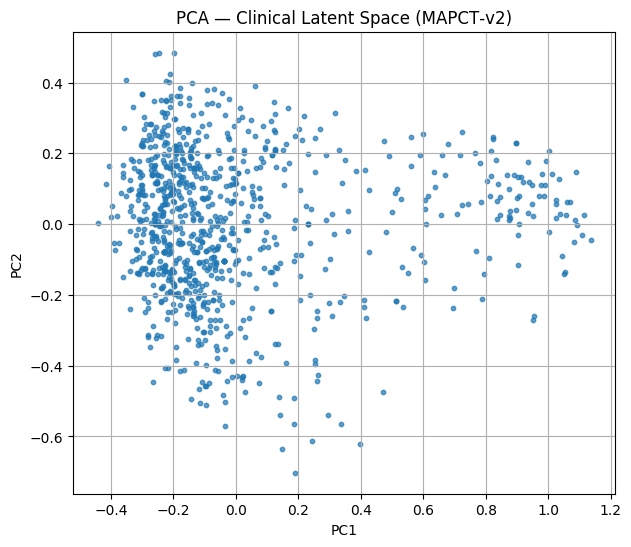

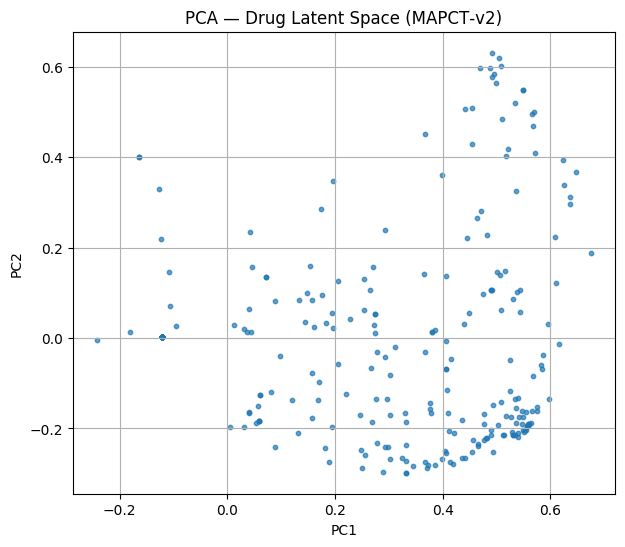

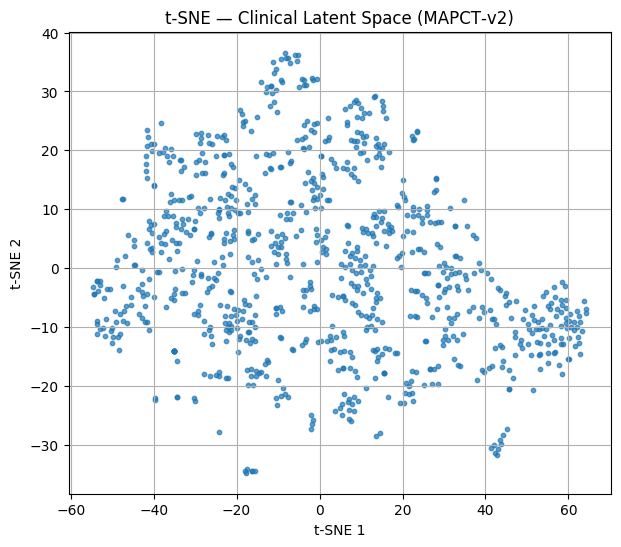

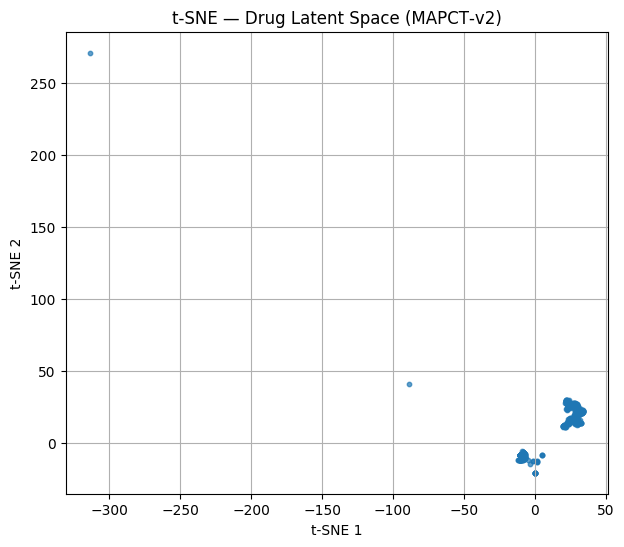

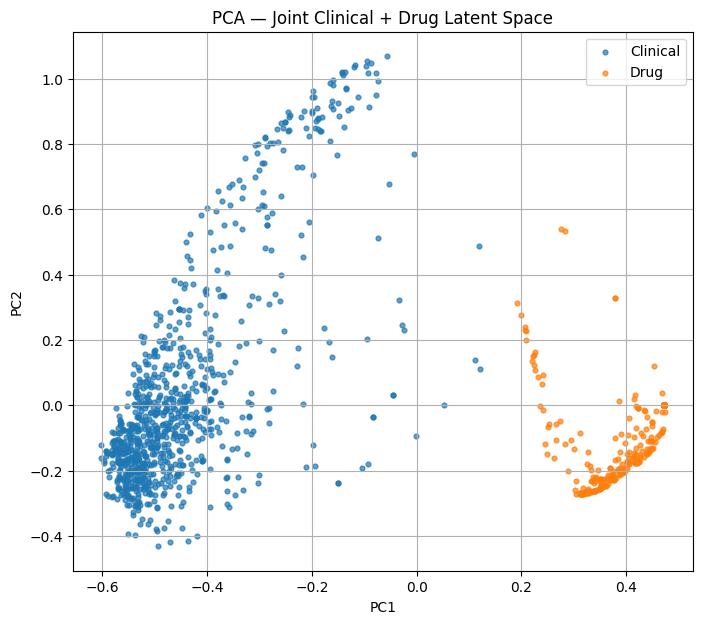

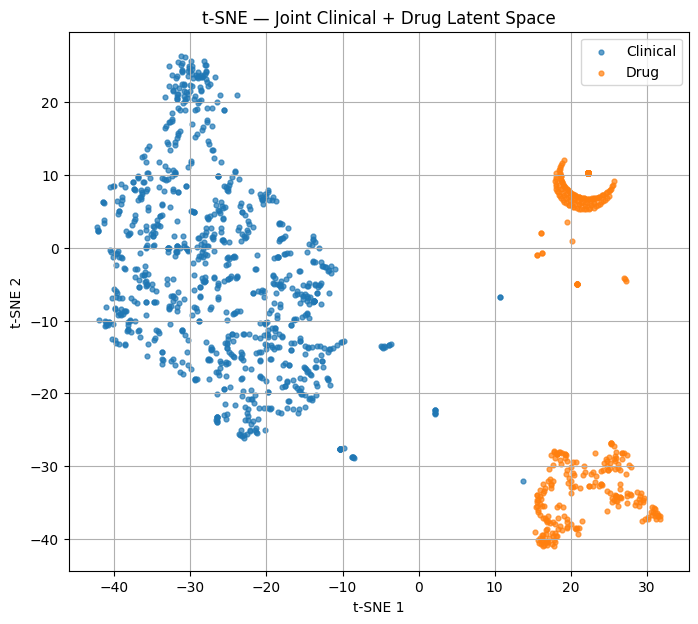

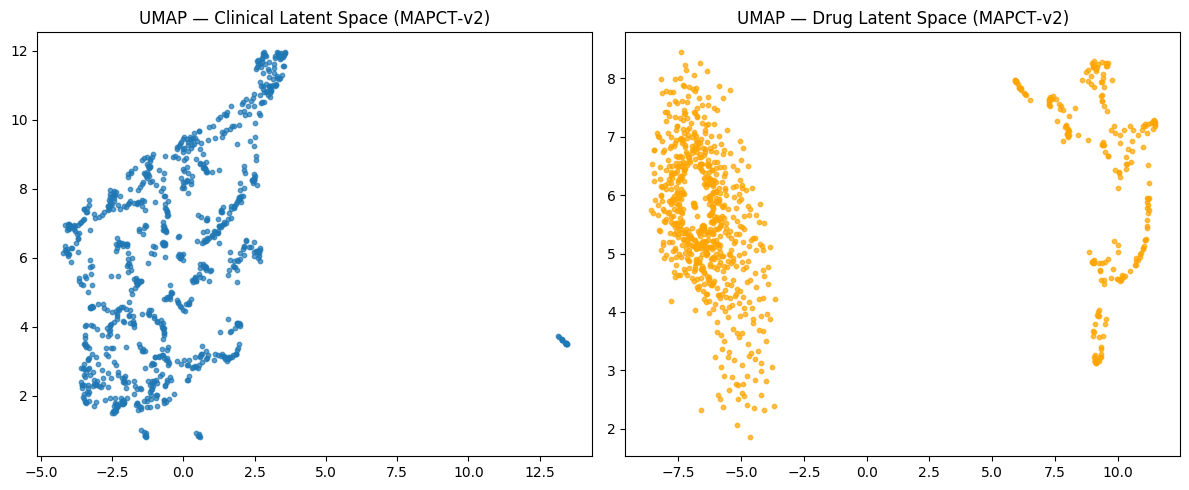

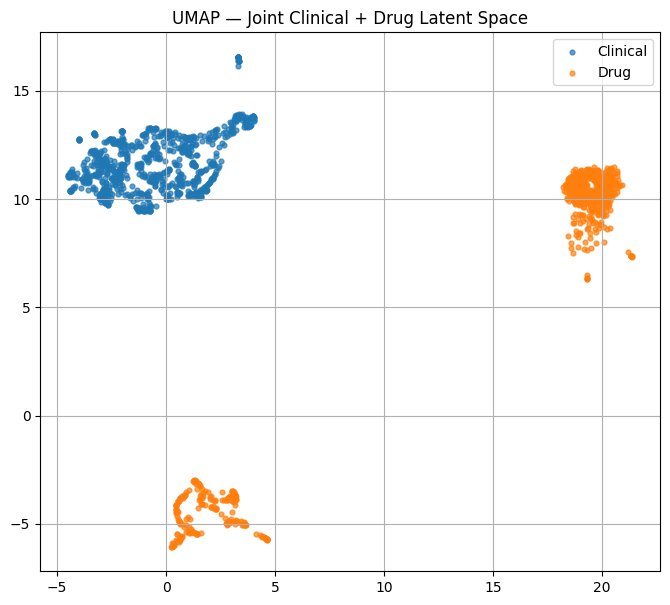

Evaluating v2: 100%|██████████| 15/15 [00:00<00:00, 19.31it/s]


MAPCT‑v2 Test Evaluation
Threshold: 0.3
Precision (micro): 0.4150
Recall    (micro): 0.5892
F1‑score  (micro): 0.4870
Accuracy (overall): 0.9849
Clinical‑Drug Alignment (mean cosine): 0.3990

✅ MAPCT‑v2 complete. No interactive loop – script finished.


In [3]:
# ============================================================
# CREATE A MODEL WRAPPER (with eval/train forwarding)
# ============================================================
class ModelWrapper:
    def __init__(self, clinical_encoder, drug_encoder, drug_decoder):
        self.clinical_encoder = clinical_encoder
        self.drug_encoder = drug_encoder
        self.drug_decoder = drug_decoder

    def eval(self):
        self.clinical_encoder.eval()
        self.drug_encoder.eval()
        self.drug_decoder.eval()
        return self

    def train(self, mode=True):
        self.clinical_encoder.train(mode)
        self.drug_encoder.train(mode)
        self.drug_decoder.train(mode)
        return self

    def to(self, device):
        self.clinical_encoder.to(device)
        self.drug_encoder.to(device)
        self.drug_decoder.to(device)
        return self

model = ModelWrapper(clinical_encoder, drug_encoder, drug_decoder)

# ============================================================
# CREATE TEST LOADER (necessary for evaluate_mapct_v2)
# ============================================================
test_dataset = TensorDataset(
    X_clin_test, X_drug_test, mask_test, role_test, y_drug_test
)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# ============================================================
# LATENT SPACE VISUALIZATION (PCA + t‑SNE + UMAP)
# ============================================================
def compute_latents(clinical_encoder, drug_encoder,
                    X_clin_test, X_drug_test, mask_test, role_test,
                    batch_size=128):
    clinical_encoder.eval()
    drug_encoder.eval()
    all_z_clin, all_z_drug = [], []
    with torch.no_grad():
        for i in range(0, len(X_clin_test), batch_size):
            x_clin = X_clin_test[i:i+batch_size]
            x_drug = X_drug_test[i:i+batch_size]
            x_mask = mask_test[i:i+batch_size]
            x_role = role_test[i:i+batch_size]
            zc = clinical_encoder(x_clin).cpu().numpy()
            zd = drug_encoder(x_drug, x_mask, x_role).cpu().numpy()
            all_z_clin.append(zc)
            all_z_drug.append(zd)
    return np.vstack(all_z_clin), np.vstack(all_z_drug)

z_clin_test, z_drug_test = compute_latents(
    clinical_encoder, drug_encoder,
    X_clin_test, X_drug_test, mask_test, role_test
)
print("Clinical latent shape:", z_clin_test.shape)
print("Drug latent shape:", z_drug_test.shape)

# ----- PCA -----
def plot_pca(z, title="PCA of Latent Space"):
    pca = PCA(n_components=2)
    z_pca = pca.fit_transform(z)
    plt.figure(figsize=(7,6))
    plt.scatter(z_pca[:,0], z_pca[:,1], s=10, alpha=0.7)
    plt.title(title); plt.xlabel("PC1"); plt.ylabel("PC2"); plt.grid(True); plt.show()

plot_pca(z_clin_test, "PCA — Clinical Latent Space (MAPCT‑v2)")
plot_pca(z_drug_test, "PCA — Drug Latent Space (MAPCT‑v2)")

# ----- t‑SNE -----
def plot_tsne(z, title="t-SNE of Latent Space", perplexity=30):
    tsne = TSNE(n_components=2, perplexity=perplexity, learning_rate=200)
    z_tsne = tsne.fit_transform(z)
    plt.figure(figsize=(7,6))
    plt.scatter(z_tsne[:,0], z_tsne[:,1], s=10, alpha=0.7)
    plt.title(title); plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2"); plt.grid(True); plt.show()

plot_tsne(z_clin_test, "t-SNE — Clinical Latent Space (MAPCT‑v2)")
plot_tsne(z_drug_test, "t-SNE — Drug Latent Space (MAPCT‑v2)")

# ----- Joint PCA -----
Z_joint = np.vstack([z_clin_test, z_drug_test])
labels = np.array(["clinical"]*len(z_clin_test) + ["drug"]*len(z_drug_test))
pca = PCA(n_components=2)
Z_pca = pca.fit_transform(Z_joint)
plt.figure(figsize=(8,7))
plt.scatter(Z_pca[labels=="clinical",0], Z_pca[labels=="clinical",1], s=12, alpha=0.7, label="Clinical")
plt.scatter(Z_pca[labels=="drug",0], Z_pca[labels=="drug",1], s=12, alpha=0.7, label="Drug")
plt.title("PCA — Joint Clinical + Drug Latent Space")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend(); plt.grid(True); plt.show()

# ----- Joint t‑SNE -----
tsne = TSNE(n_components=2, perplexity=40, learning_rate=200)
Z_tsne = tsne.fit_transform(Z_joint)
plt.figure(figsize=(8,7))
plt.scatter(Z_tsne[labels=="clinical",0], Z_tsne[labels=="clinical",1], s=12, alpha=0.7, label="Clinical")
plt.scatter(Z_tsne[labels=="drug",0], Z_tsne[labels=="drug",1], s=12, alpha=0.7, label="Drug")
plt.title("t-SNE — Joint Clinical + Drug Latent Space")
plt.xlabel("t-SNE 1"); plt.ylabel("t-SNE 2"); plt.legend(); plt.grid(True); plt.show()

# ----- UMAP (if installed) -----
try:
    import umap
    reducer = umap.UMAP(random_state=SEED)
    z_clin_umap = reducer.fit_transform(z_clin_test)
    z_drug_umap = reducer.fit_transform(z_drug_test)

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.scatter(z_clin_umap[:,0], z_clin_umap[:,1], s=10, alpha=0.7)
    plt.title("UMAP — Clinical Latent Space (MAPCT‑v2)")
    plt.subplot(1,2,2)
    plt.scatter(z_drug_umap[:,0], z_drug_umap[:,1], s=10, alpha=0.7, c='orange')
    plt.title("UMAP — Drug Latent Space (MAPCT‑v2)")
    plt.tight_layout()
    plt.show()

    # Joint UMAP
    Z_joint_umap = reducer.fit_transform(Z_joint)
    plt.figure(figsize=(8,7))
    plt.scatter(Z_joint_umap[labels=="clinical",0], Z_joint_umap[labels=="clinical",1], s=12, alpha=0.7, label="Clinical")
    plt.scatter(Z_joint_umap[labels=="drug",0], Z_joint_umap[labels=="drug",1], s=12, alpha=0.7, label="Drug")
    plt.title("UMAP — Joint Clinical + Drug Latent Space")
    plt.legend(); plt.grid(True); plt.show()
except ImportError:
    print("UMAP not installed. Skipping UMAP plots. Install with: !pip install umap-learn")


# ============================================================
# FINAL TEST EVALUATION (metrics + alignment)
# ============================================================
def evaluate_mapct_v2(model, test_loader, device, threshold=0.3):
    model.eval()   # now works because ModelWrapper has eval()
    all_preds, all_labels, align_scores = [], [], []
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating v2"):
            clinical, drug_seq, mask, role, labels = batch
            clinical = clinical.to(device)
            drug_seq = drug_seq.to(device)
            mask = mask.to(device)
            role = role.to(device)
            labels_np = labels.cpu().numpy()
            z_clin = model.clinical_encoder(clinical)
            logits = model.drug_decoder(z_clin)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > threshold).astype(int)
            all_preds.extend(preds)
            all_labels.extend(labels_np)
            z_drug = model.drug_encoder(drug_seq, mask, role)
            sim = (z_clin * z_drug).sum(dim=1).cpu().numpy()
            align_scores.extend(sim)
    y_true, y_pred = np.array(all_labels), np.array(all_preds)
    precision = precision_score(y_true, y_pred, average='micro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='micro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)
    accuracy = accuracy_score(y_true.flatten(), y_pred.flatten())
    alignment = np.mean(align_scores)
    print("\n" + "="*50)
    print("MAPCT‑v2 Test Evaluation")
    print("="*50)
    print(f"Threshold: {threshold}")
    print(f"Precision (micro): {precision:.4f}")
    print(f"Recall    (micro): {recall:.4f}")
    print(f"F1‑score  (micro): {f1:.4f}")
    print(f"Accuracy (overall): {accuracy:.4f}")
    print(f"Clinical‑Drug Alignment (mean cosine): {alignment:.4f}")
    return {'precision': precision, 'recall': recall, 'f1': f1, 'accuracy': accuracy, 'alignment': alignment}

# Run it
results_v2 = evaluate_mapct_v2(model, test_loader, device, threshold=0.3)

print("\n✅ MAPCT‑v2 complete. No interactive loop – script finished.")